# Resultados globales y por sensor

Notebook modificado para generar las figuras de resultados globales y por sensor como imágenes únicas de 2 filas y 2 columnas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ============================================================
# Configuración visual común
# ============================================================

contextos = [168, 504, 1440]

colors = {
    "Chronos-2": "#4C78A8",
    "TimeXer": "#F58518"
}

TITLE_PAD = 14  # distance between title and plot top edge (default matplotlib = 6)

plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   15,
    'axes.labelsize':   14,
    'xtick.labelsize':  13,
    'ytick.labelsize':  13,
    'legend.fontsize':  14,
    'figure.titlesize': 16,
    'axes.titlepad':    TITLE_PAD,
})

# Boosted sizes for multi-subplot figures (2+ panels per row)
MULTI_RC = {
    'axes.titlesize':   21,
    'axes.labelsize':   19,
    'xtick.labelsize':  17,
    'ytick.labelsize':  17,
    'legend.fontsize':  19,
    'axes.titlepad':    TITLE_PAD,
}

# ============================================================
# Resultados globales
# ============================================================

global_df = pd.DataFrame({
    "modelo": ["Chronos-2", "TimeXer", "Chronos-2", "TimeXer", "Chronos-2", "TimeXer"],
    "contexto": [168, 168, 504, 504, 1440, 1440],
    "MAE": [142.0036, 156.3688, 132.1277, 163.5180, 124.5253, 156.9287],
    "RMSE": [263.5178, 271.1367, 253.5412, 292.3038, 241.8582, 277.7664],
    "MASE": [0.6213, 0.6960, 0.5780, 0.7213, 0.5462, 0.7047],
    "WQL": [0.0807, 0.0923, 0.0747, 0.0971, 0.0701, 0.0912],
})

# ============================================================
# Resultados por sensor
# ============================================================

sensor_summary = pd.DataFrame([
    {
        "modelo": "Chronos-2",
        "contexto": 168,
        "MAE_medio": 139.2483,
        "RMSE_medio": 235.6131,
        "MASE_medio": 0.6215,
        "WQL_medio": 0.0875,
        "sensores_MASE_lt_1_pct": 97.4
    },
    {
        "modelo": "Chronos-2",
        "contexto": 504,
        "MAE_medio": 129.1799,
        "RMSE_medio": 225.3019,
        "MASE_medio": 0.5785,
        "WQL_medio": 0.0811,
        "sensores_MASE_lt_1_pct": 98.1
    },
    {
        "modelo": "Chronos-2",
        "contexto": 1440,
        "MAE_medio": 121.6874,
        "RMSE_medio": 217.2955,
        "MASE_medio": 0.5465,
        "WQL_medio": 0.0763,
        "sensores_MASE_lt_1_pct": 98.1
    },
    {
        "modelo": "TimeXer",
        "contexto": 168,
        "MAE_medio": 152.5025,
        "RMSE_medio": 236.7652,
        "MASE_medio": 0.6971,
        "WQL_medio": 0.1048,
        "sensores_MASE_lt_1_pct": 96.2
    },
    {
        "modelo": "TimeXer",
        "contexto": 504,
        "MAE_medio": 159.7773,
        "RMSE_medio": 258.9033,
        "MASE_medio": 0.7240,
        "WQL_medio": 0.1068,
        "sensores_MASE_lt_1_pct": 95.2
    },
    {
        "modelo": "TimeXer",
        "contexto": 1440,
        "MAE_medio": 152.8824,
        "RMSE_medio": 243.1500,
        "MASE_medio": 0.7064,
        "WQL_medio": 0.1034,
        "sensores_MASE_lt_1_pct": 96.2
    },
])

In [2]:
def plot_metrics_2x2(
    data,
    metrics,
    ylabels,
    titles,
    filename,
    suptitle=None,
    decimals=None,
    legend_loc="lower center"
):
    """
    Genera dos figuras independientes 1×2 (una por fila) con las métricas indicadas.
    Cada subgráfica compara Chronos-2 y TimeXer para los tres contextos históricos.
    """

    if decimals is None:
        decimals = {}

    x = np.arange(len(contextos))
    width = 0.34

    for row_idx in range(2):
        row_slice = slice(row_idx * 2, (row_idx + 1) * 2)
        row_metrics = metrics[row_slice]
        row_ylabels = ylabels[row_slice]
        row_titles = titles[row_slice]

        with plt.rc_context(MULTI_RC):
            fig, axes = plt.subplots(1, 2, figsize=(17, 7))

            handles = None
            labels_leg = None

            for ax, metric, ylabel, title in zip(axes, row_metrics, row_ylabels, row_titles):
                pivot = (
                    data
                    .pivot(index="contexto", columns="modelo", values=metric)
                    .reindex(contextos)
                )

                bars_chronos = ax.bar(
                    x - width / 2,
                    pivot["Chronos-2"],
                    width=width,
                    label="Chronos-2",
                    color=colors["Chronos-2"],
                    edgecolor="black",
                    linewidth=0.8
                )

                bars_timexer = ax.bar(
                    x + width / 2,
                    pivot["TimeXer"],
                    width=width,
                    label="TimeXer",
                    color=colors["TimeXer"],
                    edgecolor="black",
                    linewidth=0.8
                )

                if handles is None:
                    handles, labels_leg = ax.get_legend_handles_labels()

                ymax = pivot.max().max() * 1.18
                ax.set_ylim(0, ymax)

                dec = decimals.get(metric, 3 if "MASE" in metric or "WQL" in metric else 1)

                for bars in (bars_chronos, bars_timexer):
                    for bar in bars:
                        value = bar.get_height()
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            value + ymax * 0.015,
                            f"{value:.{dec}f}",
                            ha="center",
                            va="bottom",
                            fontsize=14
                        )

                ax.set_title(title)
                ax.set_xlabel("Contexto histórico")
                ax.set_ylabel(ylabel)
                ax.set_xticks(x)
                ax.set_xticklabels([f"{c} h" for c in contextos])
                ax.grid(axis="y", linestyle="--", alpha=0.35)
                ax.set_axisbelow(True)

                if ax.get_legend() is not None:
                    ax.get_legend().remove()

            fig.legend(
                handles,
                labels_leg,
                title="Modelo",
                loc="lower center",
                ncol=2,
                frameon=True,
                bbox_to_anchor=(0.5, 0.06)
            )
            fig.tight_layout(rect=[0, 0.22, 1, 1])

            if filename:
                base = filename.rsplit(".", 1)[0] if "." in filename else filename
                fig.savefig(f"{base}_r{row_idx + 1}.png", dpi=300, bbox_inches="tight")

            plt.show()


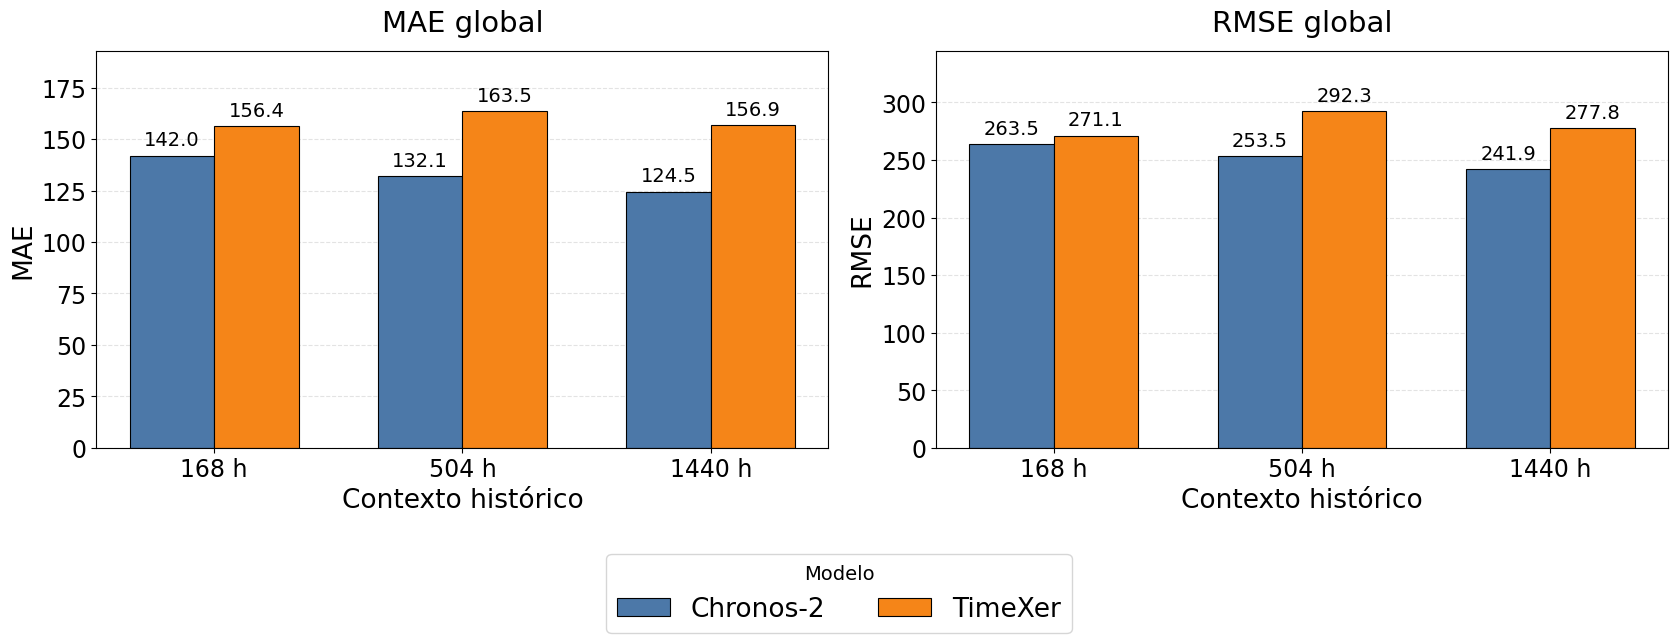

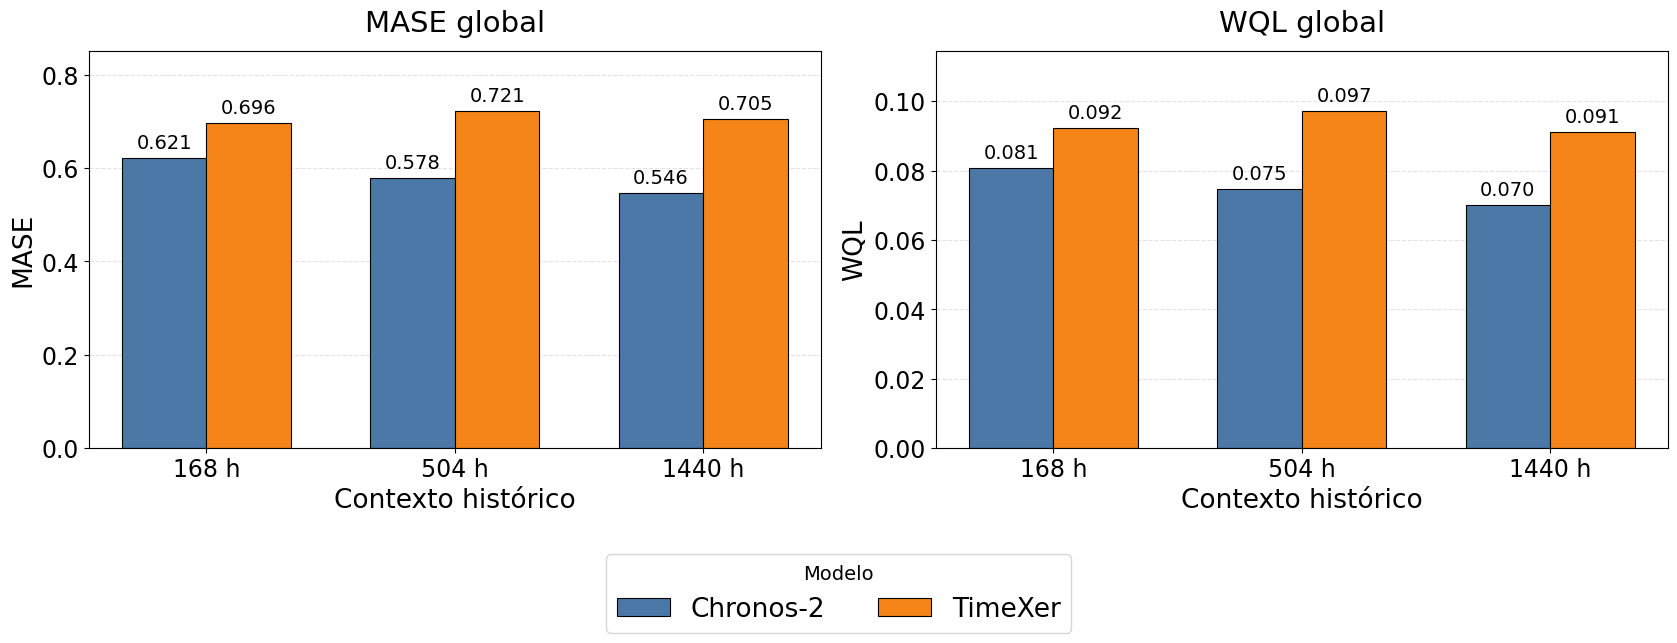

In [3]:
# ============================================================
# Figura 5.1.3: resultados globales en una única imagen 2x2
# ============================================================

plot_metrics_2x2(
    data=global_df,
    metrics=["MAE", "RMSE", "MASE", "WQL"],
    ylabels=[
        "MAE",
        "RMSE",
        "MASE",
        "WQL"
    ],
    titles=[
        "MAE global",
        "RMSE global",
        "MASE global",
        "WQL global"
    ],
    filename="fig_5_1_3_resultados_globales_2x2.png",
    suptitle="Resultados globales por modelo y contexto",
    decimals={
        "MAE": 1,
        "RMSE": 1,
        "MASE": 3,
        "WQL": 3
    }
)

In [4]:
# ============================================================
# Tabla resumen simplificada para el apartado 5.1.4
# ============================================================

tabla_514_media = sensor_summary.copy()

tabla_514_media["Contexto"] = tabla_514_media["contexto"].astype(str) + " h"
tabla_514_media["Sensores con MASE < 1"] = tabla_514_media["sensores_MASE_lt_1_pct"].map(lambda x: f"{x:.1f} %")

tabla_514_media = tabla_514_media[[
    "modelo",
    "Contexto",
    "MAE_medio",
    "RMSE_medio",
    "MASE_medio",
    "WQL_medio",
    "Sensores con MASE < 1"
]]

tabla_514_media = tabla_514_media.rename(columns={
    "modelo": "Modelo",
    "MAE_medio": "MAE medio por sensor",
    "RMSE_medio": "RMSE medio por sensor",
    "MASE_medio": "MASE medio por sensor",
    "WQL_medio": "WQL medio por sensor"
})

display(
    tabla_514_media.style.format({
        "MAE medio por sensor": "{:.2f}",
        "RMSE medio por sensor": "{:.2f}",
        "MASE medio por sensor": "{:.3f}",
        "WQL medio por sensor": "{:.3f}",
    })
)

,Modelo,Contexto,MAE medio por sensor,RMSE medio por sensor,MASE medio por sensor,WQL medio por sensor,Sensores con MASE < 1
0,Chronos-2,168 h,139.25,235.61,0.622,0.087,97.4 %
1,Chronos-2,504 h,129.18,225.30,0.579,0.081,98.1 %
2,Chronos-2,1440 h,121.69,217.30,0.546,0.076,98.1 %
3,TimeXer,168 h,152.50,236.77,0.697,0.105,96.2 %
4,TimeXer,504 h,159.78,258.90,0.724,0.107,95.2 %
5,TimeXer,1440 h,152.88,243.15,0.706,0.103,96.2 %


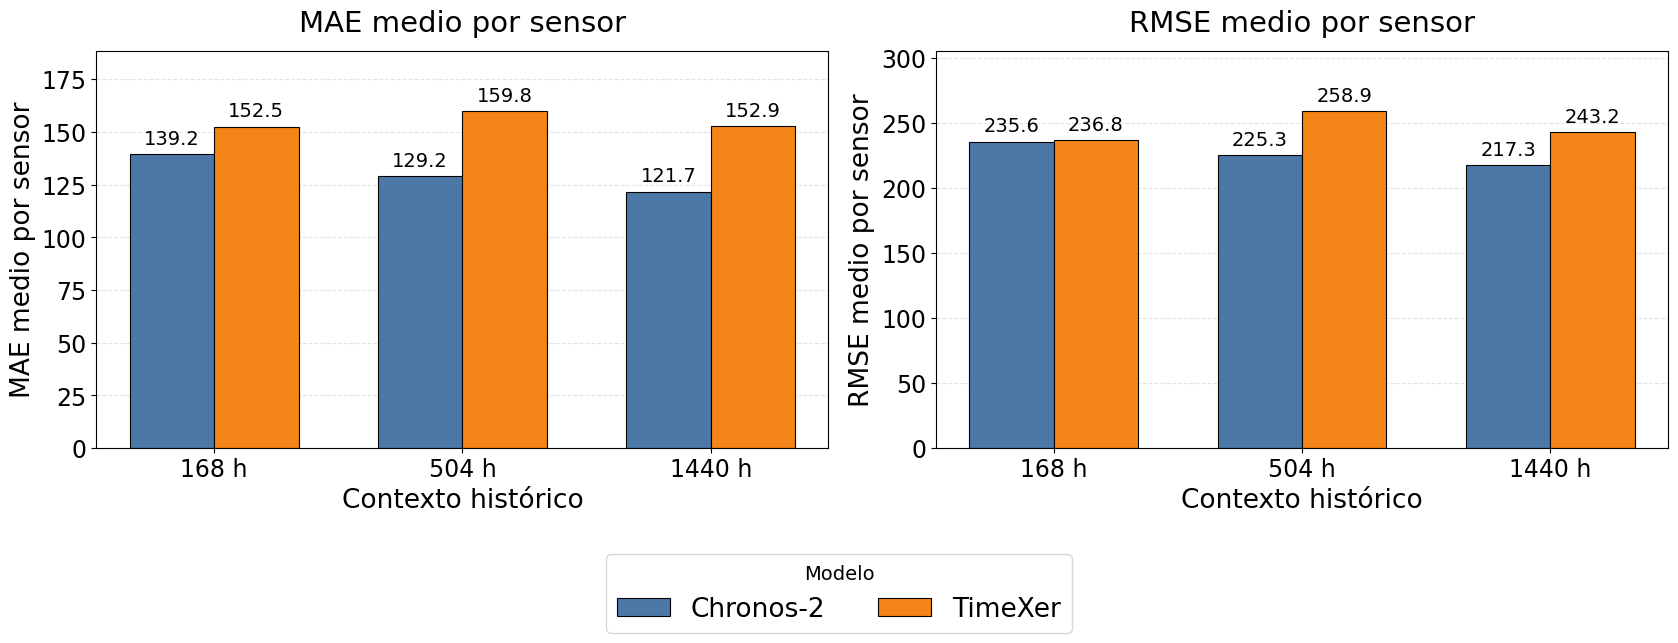

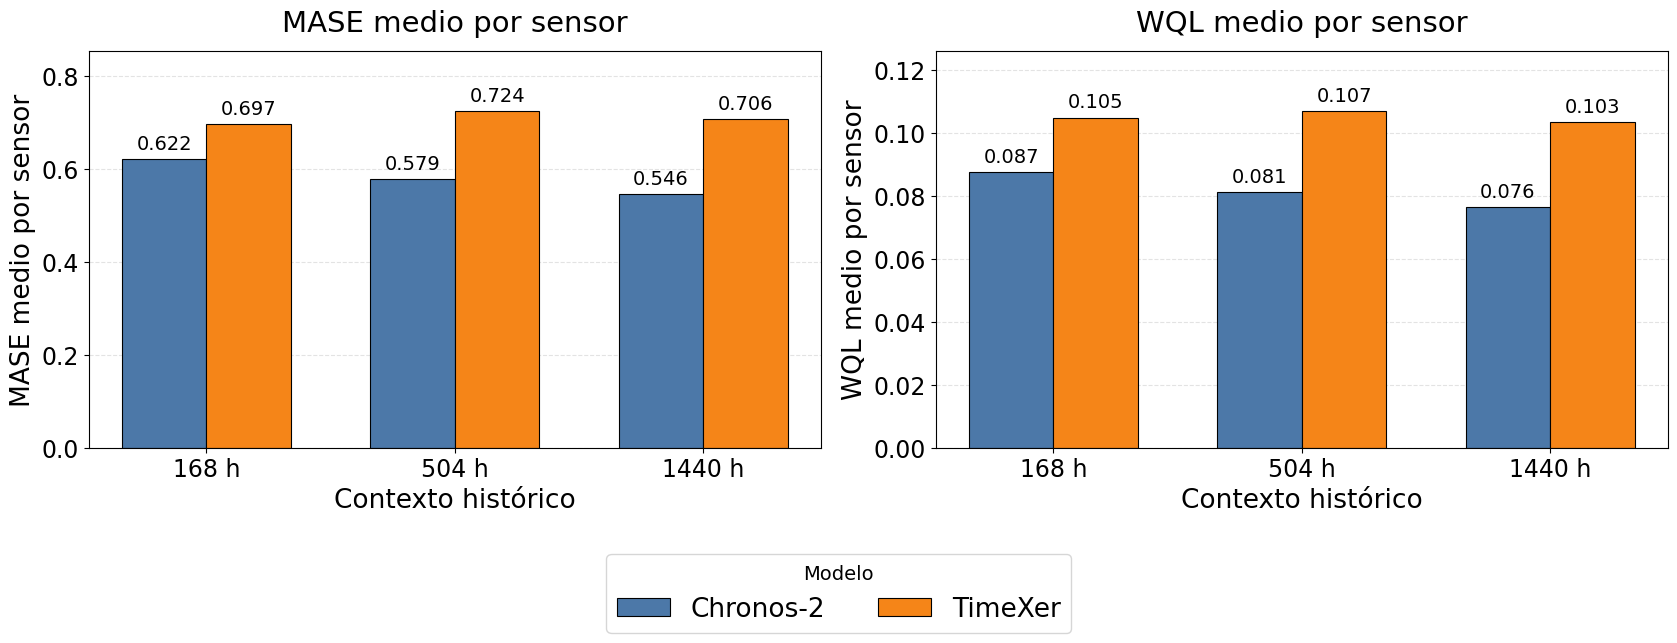

In [5]:
# ============================================================
# Figura 5.1.4: resultados por sensor en una única imagen 2x2
# ============================================================

plot_metrics_2x2(
    data=sensor_summary,
    metrics=["MAE_medio", "RMSE_medio", "MASE_medio", "WQL_medio"],
    ylabels=[
        "MAE medio por sensor",
        "RMSE medio por sensor",
        "MASE medio por sensor",
        "WQL medio por sensor"
    ],
    titles=[
        "MAE medio por sensor",
        "RMSE medio por sensor",
        "MASE medio por sensor",
        "WQL medio por sensor"
    ],
    filename="fig_5_1_4_resultados_por_sensor_2x2.png",
    suptitle="Resultados por sensor según modelo y contexto",
    decimals={
        "MAE_medio": 1,
        "RMSE_medio": 1,
        "MASE_medio": 3,
        "WQL_medio": 3
    }
)

### 5.1.5 Evolución de métricas por ventana rolling — finalistas (Chronos-2 1440H vs TimeXer 168H)

Comparativa unificada de la evolución de cada métrica a lo largo de las 59 ventanas rolling para los dos modelos
finalistas. Une en una sola gráfica por métrica lo que antes eran paneles separados por modelo y horizonte. La línea
discontinua marca la media de cada modelo (sin banda ±1 DT para evitar saturar la comparación de dos series).

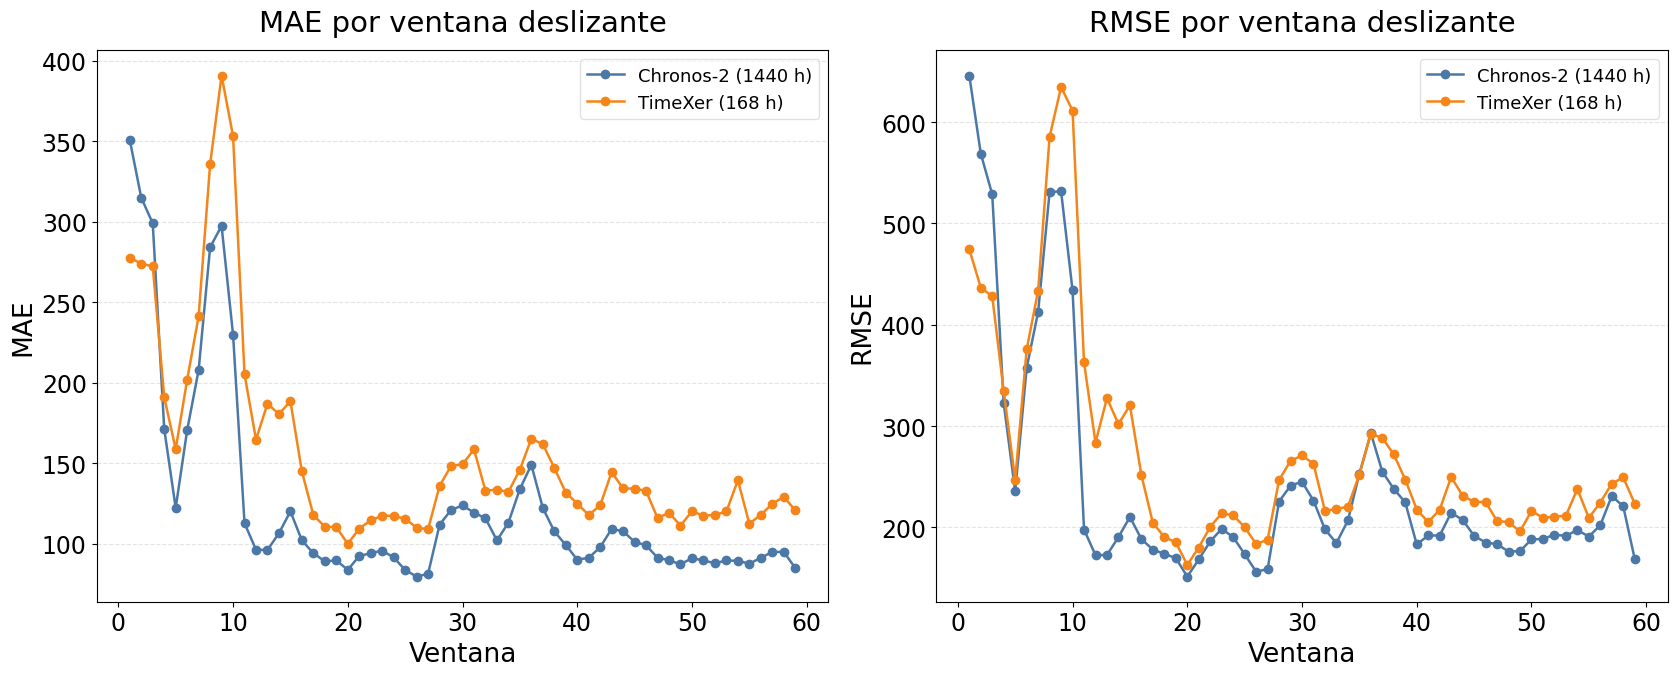

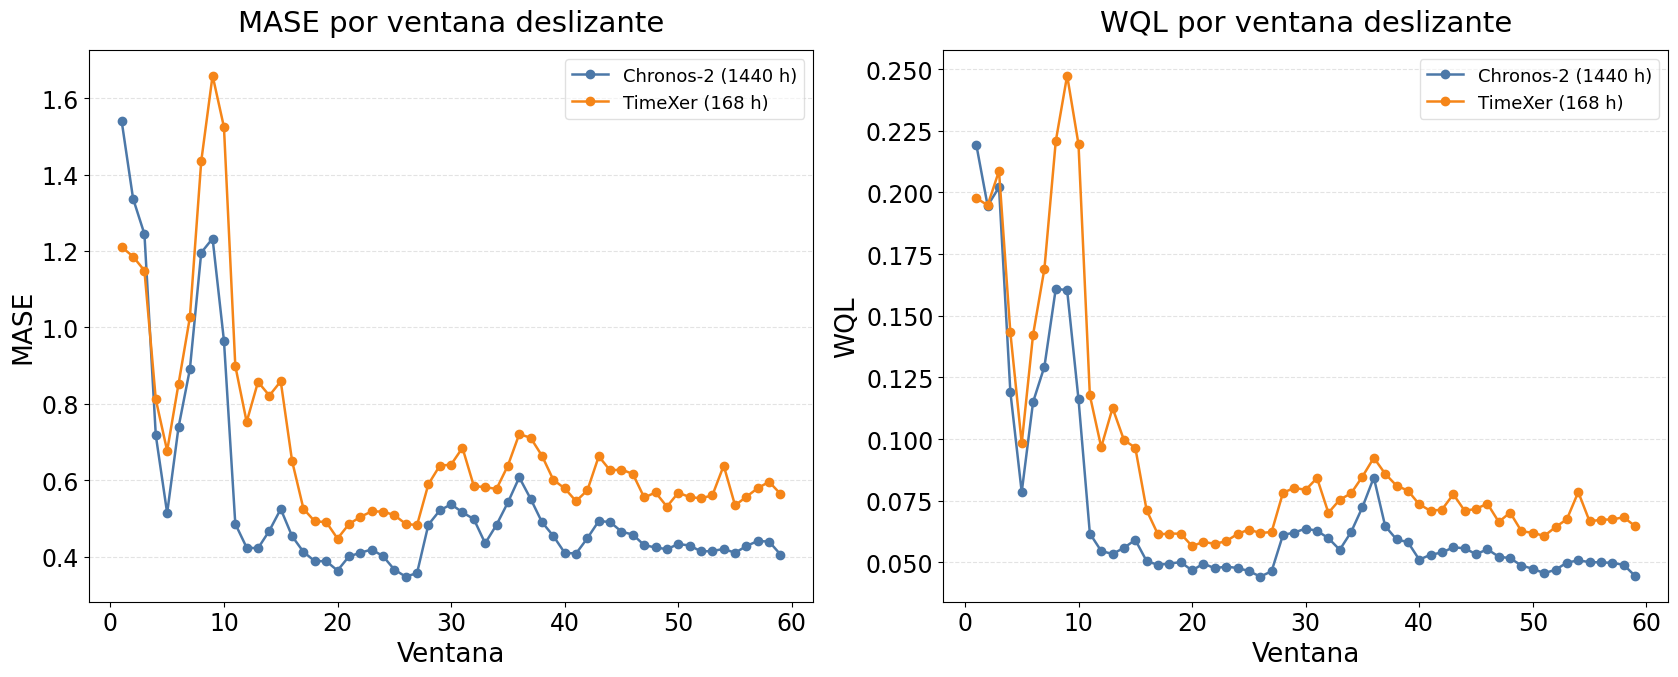

In [6]:
# ============================================================
# Figura 5.1.5: evolución de métricas por ventana rolling
# Chronos-2 (1440H) vs TimeXer (168H) — una gráfica por métrica
# Datos extraídos de los notebooks 4-chronos-2-PL96-HH1440 y
# 4-timexer-PL96-HH168 (sección "Per-window metrics").
# ============================================================

chronos_win = pd.read_csv("rolling_window_metrics_chronos2_1440H.csv")
timexer_win = pd.read_csv("rolling_window_metrics_timexer_168H.csv")

metric_cols = ["MAE", "RMSE", "MASE", "WQL"]

series = {
    "Chronos-2 (1440 h)": (chronos_win, colors["Chronos-2"]),
    "TimeXer (168 h)":    (timexer_win, colors["TimeXer"]),
}

metric_pairs = [metric_cols[:2], metric_cols[2:]]  # 2 paneles por fila

for row_idx, pair in enumerate(metric_pairs):
    with plt.rc_context(MULTI_RC):
        fig, axes = plt.subplots(1, 2, figsize=(17, 7))

        for ax, metric in zip(axes, pair):
            for label, (dfw, color) in series.items():
                ax.plot(
                    dfw["window"] + 1, dfw[metric],
                    marker="o", linewidth=1.8, color=color, label=label,
                )

            ax.set_xlabel("Ventana")
            ax.set_ylabel(metric)
            ax.set_title(f"{metric} por ventana deslizante")
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.set_axisbelow(True)
            ax.legend(fontsize=13, framealpha=0.6)

        fig.tight_layout()
        fig.savefig(
            f"fig_5_1_5_evolucion_rolling_finalistas_r{row_idx + 1}.png",
            dpi=300, bbox_inches="tight",
        )
        plt.show()


,Modelo,Contexto,Tipo,Entrenamiento,Tiempo entrenamiento,Tiempo inferencia,Inferencia por ventana,Inferencia por observación válida,MAE,RMSE,MASE,WQL
0,Chronos-2,1440 h,Fundacional zero-shot,No aplica,No aplica,1 h 48 min 57 s,110.80 s,3.658 ms,124.53,241.86,0.5462,0.0701
1,TimeXer,168 h,Especialista supervisado,Sí,59 min 17 s,57 s,0.97 s,0.032 ms,156.37,271.14,0.6960,0.0923


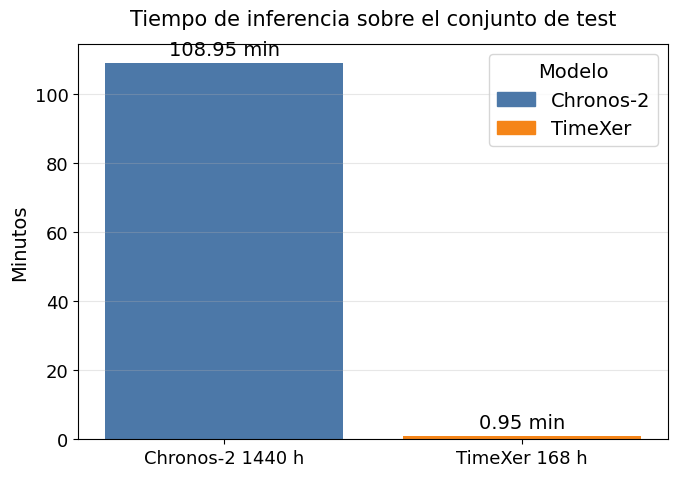

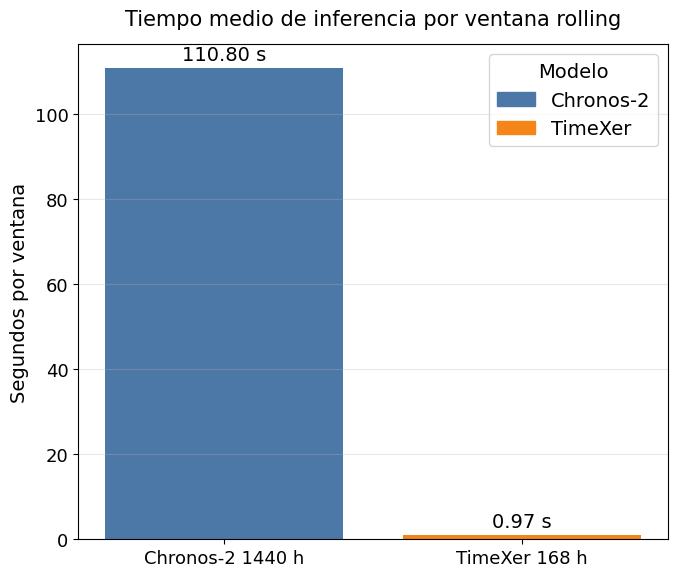

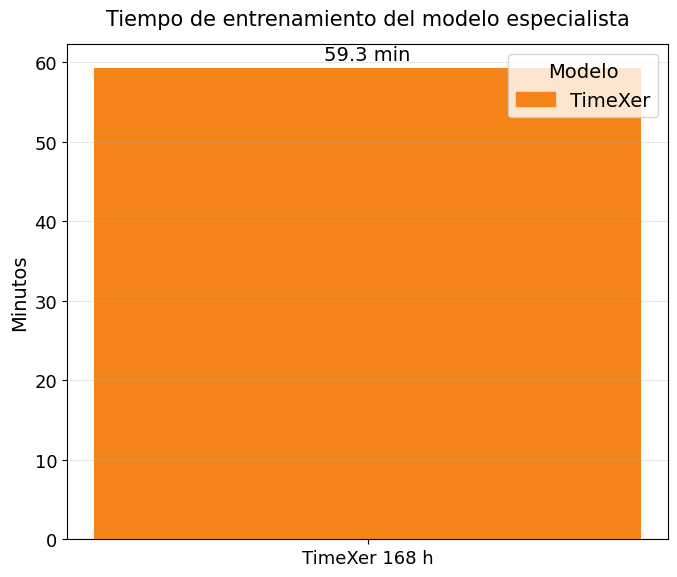

Resumen:
- Chronos-2 1440 h no requiere entrenamiento y tarda 1 h 48 min 57 s en inferencia.
- TimeXer 168 h requiere 59 min 17 s de entrenamiento y 57 s de inferencia.
- La inferencia de Chronos-2 es aproximadamente 114.7 veces más lenta que la de TimeXer en estos escenarios finalistas.
- TimeXer, una vez entrenado, es mucho más eficiente en inferencia, aunque obtiene peor precisión global.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 5.1.6 Coste computacional — escenarios finalistas
# ============================================================

N_WINDOWS = 59
N_VALID_ROWS = 1_787_046

colors = {
    "Chronos-2": "#4C78A8",
    "TimeXer": "#F58518"
}

def hms_to_seconds(hours=0, minutes=0, seconds=0):
    return hours * 3600 + minutes * 60 + seconds

def format_seconds(total_seconds):
    total_seconds = int(round(total_seconds))
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    if h > 0:
        return f"{h} h {m} min {s} s"
    if m > 0:
        return f"{m} min {s} s"
    return f"{s} s"

data = [
    {
        "Modelo": "Chronos-2",
        "Contexto": "1440 h",
        "Tipo": "Fundacional zero-shot",
        "Entrenamiento": "No aplica",
        "Tiempo entrenamiento (s)": np.nan,
        "Tiempo inferencia (s)": hms_to_seconds(hours=1, minutes=48, seconds=57),
        "MAE": 124.53,
        "RMSE": 241.86,
        "MASE": 0.5462,
        "WQL": 0.0701,
    },
    {
        "Modelo": "TimeXer",
        "Contexto": "168 h",
        "Tipo": "Especialista supervisado",
        "Entrenamiento": "Sí",
        "Tiempo entrenamiento (s)": hms_to_seconds(minutes=59, seconds=17),
        "Tiempo inferencia (s)": hms_to_seconds(seconds=57),
        "MAE": 156.37,
        "RMSE": 271.14,
        "MASE": 0.6960,
        "WQL": 0.0923,
    },
]

df = pd.DataFrame(data)

df["Inferencia por ventana (s)"] = df["Tiempo inferencia (s)"] / N_WINDOWS
df["Inferencia por observación válida (ms)"] = (
    df["Tiempo inferencia (s)"] * 1000 / N_VALID_ROWS
)

# Tabla formateada
df_table = df.copy()
df_table["Tiempo entrenamiento"] = df_table["Tiempo entrenamiento (s)"].apply(
    lambda x: "No aplica" if pd.isna(x) else format_seconds(x)
)
df_table["Tiempo inferencia"] = df_table["Tiempo inferencia (s)"].apply(format_seconds)
df_table["Inferencia por ventana"] = df_table["Inferencia por ventana (s)"].map(lambda x: f"{x:.2f} s")
df_table["Inferencia por observación válida"] = df_table["Inferencia por observación válida (ms)"].map(lambda x: f"{x:.3f} ms")

table_cols = [
    "Modelo",
    "Contexto",
    "Tipo",
    "Entrenamiento",
    "Tiempo entrenamiento",
    "Tiempo inferencia",
    "Inferencia por ventana",
    "Inferencia por observación válida",
    "MAE",
    "RMSE",
    "MASE",
    "WQL",
]

display(df_table[table_cols])

df_table[table_cols].to_csv("tabla_coste_computacional_finalistas.csv", index=False)

# ============================================================
# Figura 1: coste de inferencia comparable
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

labels = df["Modelo"] + " " + df["Contexto"]
values = df["Tiempo inferencia (s)"] / 60
bar_colors = [colors[m] for m in df["Modelo"]]

bars = ax.bar(labels, values, color=bar_colors)

ax.set_title("Tiempo de inferencia sobre el conjunto de test")
ax.set_ylabel("Minutos")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f} min",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["Chronos-2"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["TimeXer"])
]
ax.legend(legend_handles, ["Chronos-2", "TimeXer"], title="Modelo")

plt.tight_layout()
plt.savefig("figura_inferencia_test_finalistas.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Figura 2: inferencia media por ventana rolling
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

values = df["Inferencia por ventana (s)"]
bars = ax.bar(labels, values, color=bar_colors)

ax.set_title("Tiempo medio de inferencia por ventana rolling")
ax.set_ylabel("Segundos por ventana")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f} s",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors["Chronos-2"]),
    plt.Rectangle((0, 0), 1, 1, color=colors["TimeXer"])
]
ax.legend(legend_handles, ["Chronos-2", "TimeXer"], title="Modelo")

plt.tight_layout()
plt.savefig("figura_inferencia_por_ventana_finalistas.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Figura 3: coste de entrenamiento del modelo especialista
# ============================================================

timexer_train = df[df["Modelo"] == "TimeXer"].iloc[0]["Tiempo entrenamiento (s)"] / 60

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(["TimeXer 168 h"], [timexer_train], color=colors["TimeXer"])

ax.set_title("Tiempo de entrenamiento del modelo especialista")
ax.set_ylabel("Minutos")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

ax.annotate(
    f"{timexer_train:.1f} min",
    xy=(0, timexer_train),
    xytext=(0, 3),
    textcoords="offset points",
    ha="center",
    va="bottom"
)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colors["TimeXer"])]
ax.legend(legend_handles, ["TimeXer"], title="Modelo")

plt.tight_layout()
plt.savefig("figura_entrenamiento_timexer_168.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Resumen numérico
# ============================================================

chronos = df[df["Modelo"] == "Chronos-2"].iloc[0]
timexer = df[df["Modelo"] == "TimeXer"].iloc[0]

ratio_inference = chronos["Tiempo inferencia (s)"] / timexer["Tiempo inferencia (s)"]

print("Resumen:")
print(f"- Chronos-2 1440 h no requiere entrenamiento y tarda {format_seconds(chronos['Tiempo inferencia (s)'])} en inferencia.")
print(f"- TimeXer 168 h requiere {format_seconds(timexer['Tiempo entrenamiento (s)'])} de entrenamiento y {format_seconds(timexer['Tiempo inferencia (s)'])} de inferencia.")
print(f"- La inferencia de Chronos-2 es aproximadamente {ratio_inference:.1f} veces más lenta que la de TimeXer en estos escenarios finalistas.")
print(f"- TimeXer, una vez entrenado, es mucho más eficiente en inferencia, aunque obtiene peor precisión global.")

,Modelo,Contexto,Tipo,Entrenamiento,Tiempo entrenamiento,Tiempo inferencia test,Inferencia por ventana rolling,MAE,RMSE,MASE,WQL
0,Chronos-2,1440 h,Fundacional zero-shot,No aplica,No aplica,1 h 48 min 57 s,110.80 s,124.53,241.86,0.5462,0.0701
1,TimeXer,168 h,Especialista supervisado,Sí,59 min 17 s,57 s,0.97 s,156.37,271.14,0.6960,0.0923


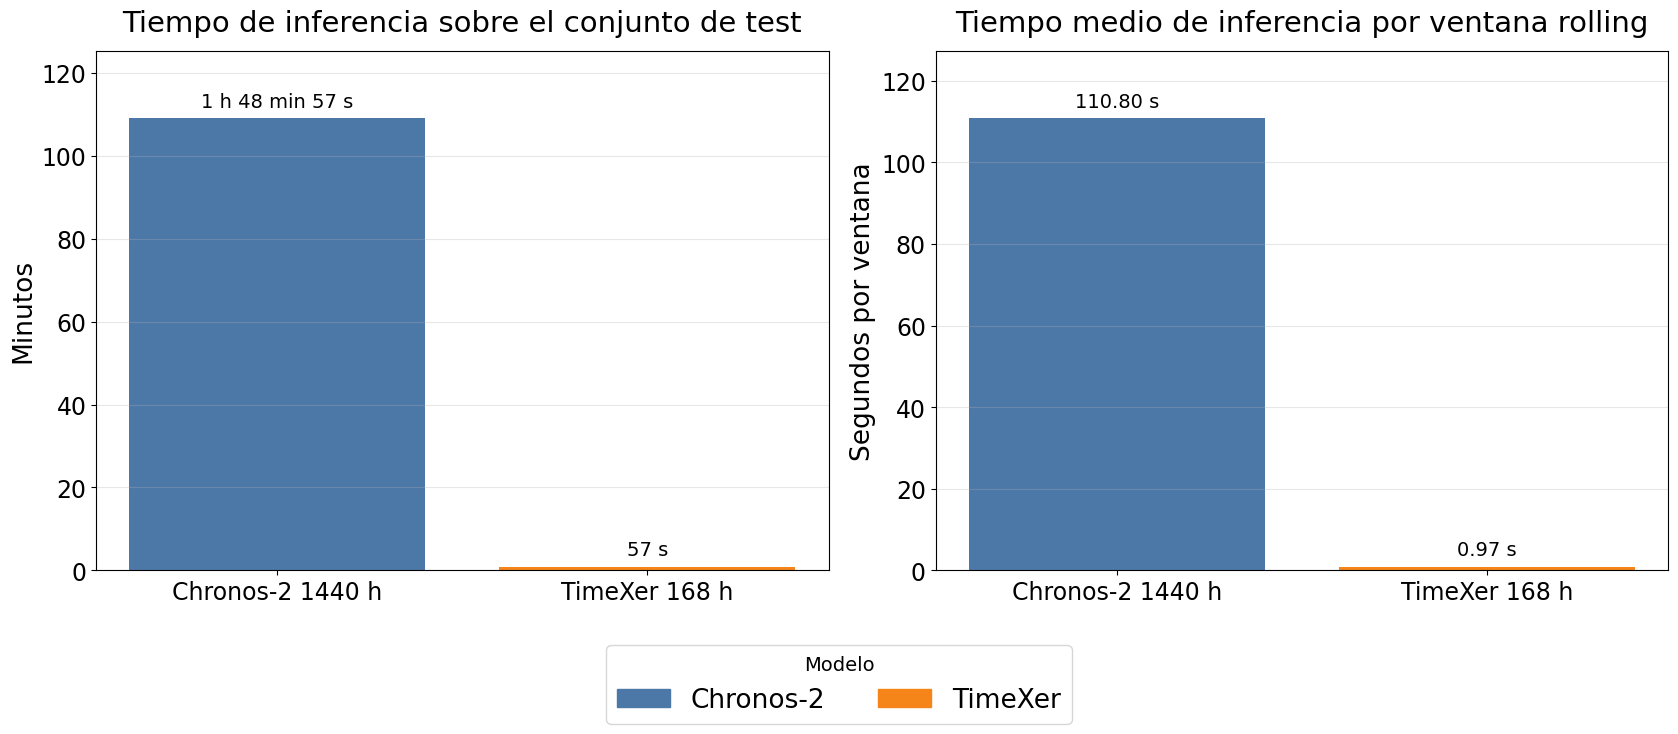

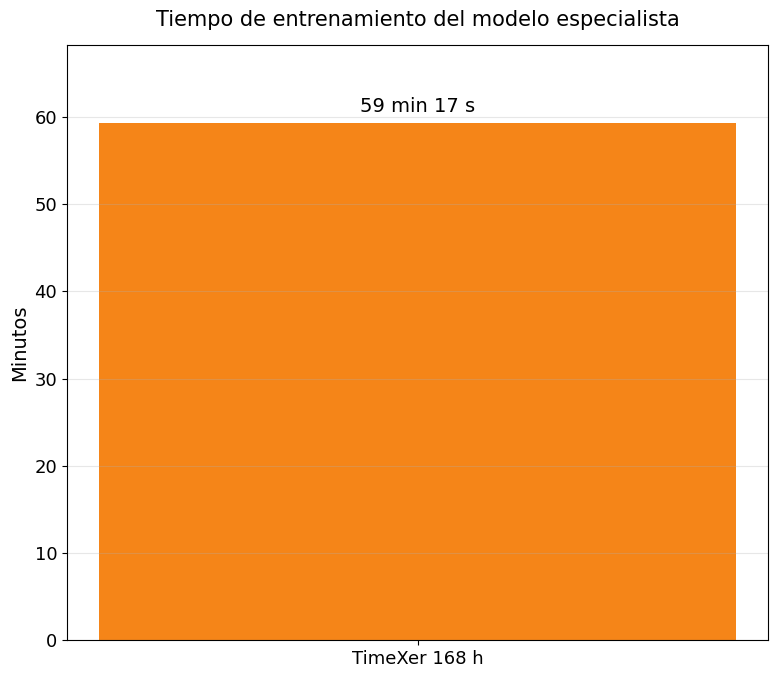

Resumen:
- Chronos-2 1440 h no requiere entrenamiento específico y tarda 1 h 48 min 57 s en inferencia.
- TimeXer 168 h requiere 59 min 17 s de entrenamiento y 57 s de inferencia.
- La inferencia de Chronos-2 es aproximadamente 114.7 veces más lenta que la de TimeXer en los escenarios finalistas.
- TimeXer, una vez entrenado, presenta una inferencia mucho más eficiente, aunque obtiene peor precisión global.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 5.1.6 Coste computacional — escenarios finalistas
# ============================================================

N_WINDOWS = 59

colors = {
    "Chronos-2": "#4C78A8",
    "TimeXer": "#F58518"
}

def hms_to_seconds(hours=0, minutes=0, seconds=0):
    return hours * 3600 + minutes * 60 + seconds

def format_seconds(total_seconds):
    total_seconds = int(round(total_seconds))
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60

    if h > 0:
        return f"{h} h {m} min {s} s"
    if m > 0:
        return f"{m} min {s} s"
    return f"{s} s"

# ============================================================
# Datos hardcodeados a partir de los notebooks finalistas
# ============================================================

data = [
    {
        "Modelo": "Chronos-2",
        "Contexto": "1440 h",
        "Tipo": "Fundacional zero-shot",
        "Entrenamiento": "No aplica",
        "Tiempo entrenamiento (s)": np.nan,
        "Tiempo inferencia (s)": hms_to_seconds(hours=1, minutes=48, seconds=57),
        "MAE": 124.53,
        "RMSE": 241.86,
        "MASE": 0.5462,
        "WQL": 0.0701,
    },
    {
        "Modelo": "TimeXer",
        "Contexto": "168 h",
        "Tipo": "Especialista supervisado",
        "Entrenamiento": "Sí",
        "Tiempo entrenamiento (s)": hms_to_seconds(minutes=59, seconds=17),
        "Tiempo inferencia (s)": hms_to_seconds(seconds=57),
        "MAE": 156.37,
        "RMSE": 271.14,
        "MASE": 0.6960,
        "WQL": 0.0923,
    },
]

df = pd.DataFrame(data)

# Métricas derivadas
df["Inferencia por ventana rolling (s)"] = df["Tiempo inferencia (s)"] / N_WINDOWS

# ============================================================
# Tabla formateada para el TFM
# ============================================================

df_table = df.copy()

df_table["Tiempo entrenamiento"] = df_table["Tiempo entrenamiento (s)"].apply(
    lambda x: "No aplica" if pd.isna(x) else format_seconds(x)
)

df_table["Tiempo inferencia test"] = df_table["Tiempo inferencia (s)"].apply(format_seconds)

df_table["Inferencia por ventana rolling"] = df_table[
    "Inferencia por ventana rolling (s)"
].map(lambda x: f"{x:.2f} s")

table_cols = [
    "Modelo",
    "Contexto",
    "Tipo",
    "Entrenamiento",
    "Tiempo entrenamiento",
    "Tiempo inferencia test",
    "Inferencia por ventana rolling",
    "MAE",
    "RMSE",
    "MASE",
    "WQL",
]

display(df_table[table_cols])

df_table[table_cols].to_csv(
    "tabla_coste_entrenamiento_inferencia_finalistas.csv",
    index=False
)

# ============================================================
# Figura 1: comparativa de tiempos de inferencia
# Panel A: tiempo total de inferencia sobre test
# Panel B: tiempo medio de inferencia por ventana rolling
# ============================================================

labels = df["Modelo"] + " " + df["Contexto"]
bar_colors = [colors[m] for m in df["Modelo"]]

with plt.rc_context(MULTI_RC):
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))

    # ------------------------------------------------------------
    # Panel A: tiempo total de inferencia
    # ------------------------------------------------------------

    values_total = df["Tiempo inferencia (s)"] / 60

    bars = axes[0].bar(labels, values_total, color=bar_colors)

    axes[0].set_title("Tiempo de inferencia sobre el conjunto de test")
    axes[0].set_ylabel("Minutos")
    axes[0].set_xlabel("")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].set_ylim(0, max(values_total) * 1.15)

    for bar, seconds in zip(bars, df["Tiempo inferencia (s)"]):
        height = bar.get_height()
        axes[0].annotate(
            format_seconds(seconds),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

    # ------------------------------------------------------------
    # Panel B: tiempo medio de inferencia por ventana rolling
    # ------------------------------------------------------------

    values_window = df["Inferencia por ventana rolling (s)"]

    bars = axes[1].bar(labels, values_window, color=bar_colors)

    axes[1].set_title("Tiempo medio de inferencia por ventana rolling")
    axes[1].set_ylabel("Segundos por ventana")
    axes[1].set_xlabel("")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_ylim(0, max(values_window) * 1.15)

    for bar in bars:
        height = bar.get_height()
        axes[1].annotate(
            f"{height:.2f} s",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

    # ------------------------------------------------------------
    # Leyenda común
    # ------------------------------------------------------------

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["Chronos-2"]),
        plt.Rectangle((0, 0), 1, 1, color=colors["TimeXer"])
    ]

    fig.legend(
        legend_handles,
        ["Chronos-2", "TimeXer"],
        title="Modelo",
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.07)
    )

    plt.tight_layout(rect=[0, 0.09, 1, 1])
    plt.savefig("figura_coste_inferencia_finalistas.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# Figura 2: coste de entrenamiento del modelo especialista
# ============================================================

timexer_train = df[df["Modelo"] == "TimeXer"].iloc[0]["Tiempo entrenamiento (s)"] / 60

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.bar(
    ["TimeXer 168 h"],
    [timexer_train],
    color=colors["TimeXer"]
)

ax.set_title("Tiempo de entrenamiento del modelo especialista")
ax.set_ylabel("Minutos")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, timexer_train * 1.15)

ax.annotate(
    format_seconds(df[df["Modelo"] == "TimeXer"].iloc[0]["Tiempo entrenamiento (s)"]),
    xy=(0, timexer_train),
    xytext=(0, 5),
    textcoords="offset points",
    ha="center",
    va="bottom"
)

plt.tight_layout()
plt.savefig("figura_entrenamiento_timexer_168.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Resumen numérico
# ============================================================

chronos = df[df["Modelo"] == "Chronos-2"].iloc[0]
timexer = df[df["Modelo"] == "TimeXer"].iloc[0]

ratio_inference = chronos["Tiempo inferencia (s)"] / timexer["Tiempo inferencia (s)"]

print("Resumen:")
print(
    f"- Chronos-2 1440 h no requiere entrenamiento específico "
    f"y tarda {format_seconds(chronos['Tiempo inferencia (s)'])} en inferencia."
)
print(
    f"- TimeXer 168 h requiere {format_seconds(timexer['Tiempo entrenamiento (s)'])} "
    f"de entrenamiento y {format_seconds(timexer['Tiempo inferencia (s)'])} de inferencia."
)
print(
    f"- La inferencia de Chronos-2 es aproximadamente "
    f"{ratio_inference:.1f} veces más lenta que la de TimeXer "
    f"en los escenarios finalistas."
)
print(
    "- TimeXer, una vez entrenado, presenta una inferencia mucho más eficiente, "
    "aunque obtiene peor precisión global."
)

### 5.1.7 Predicción vs real — sensores representativos finalistas (Chronos-2 1440H vs TimeXer 168H)

Comparativa unificada de la última ventana rolling (96 h) para los tres sensores representativos (tráfico bajo, medio y
alto). Une en una sola gráfica por sensor la predicción mediana de cada modelo finalista junto con la serie real, con
las bandas de incertidumbre P10–P90 de ambos. Solo se muestra el tramo de predicción (no el historial previo).

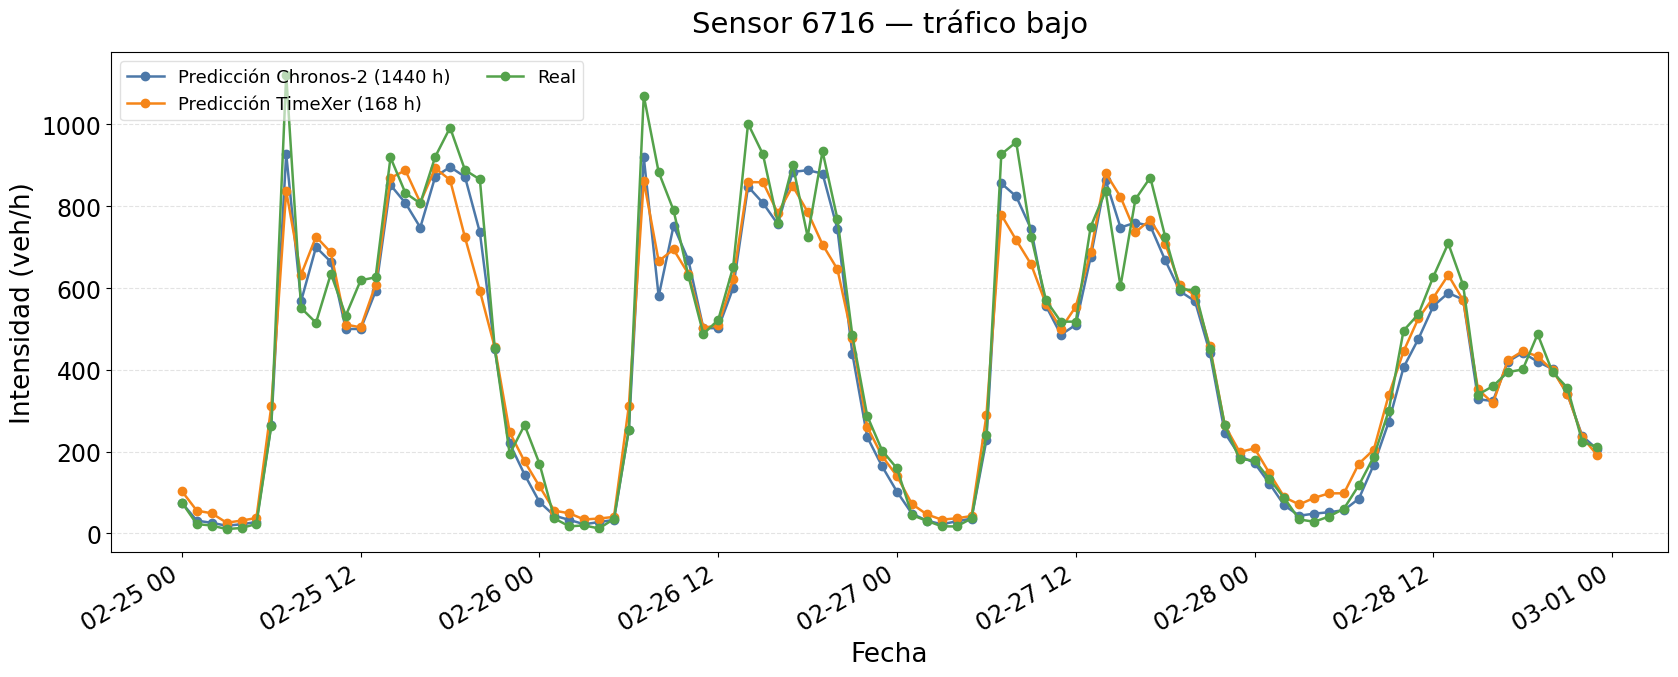

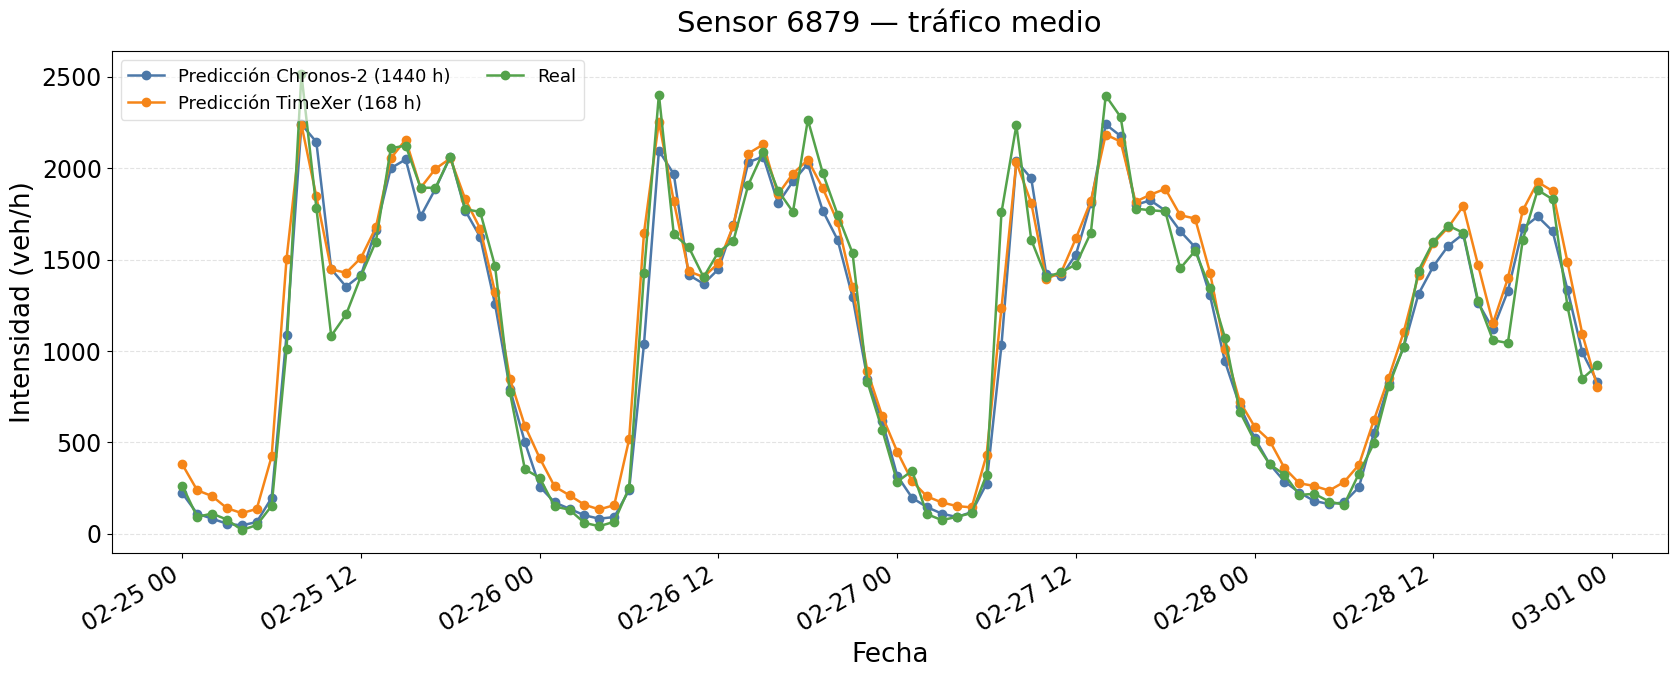

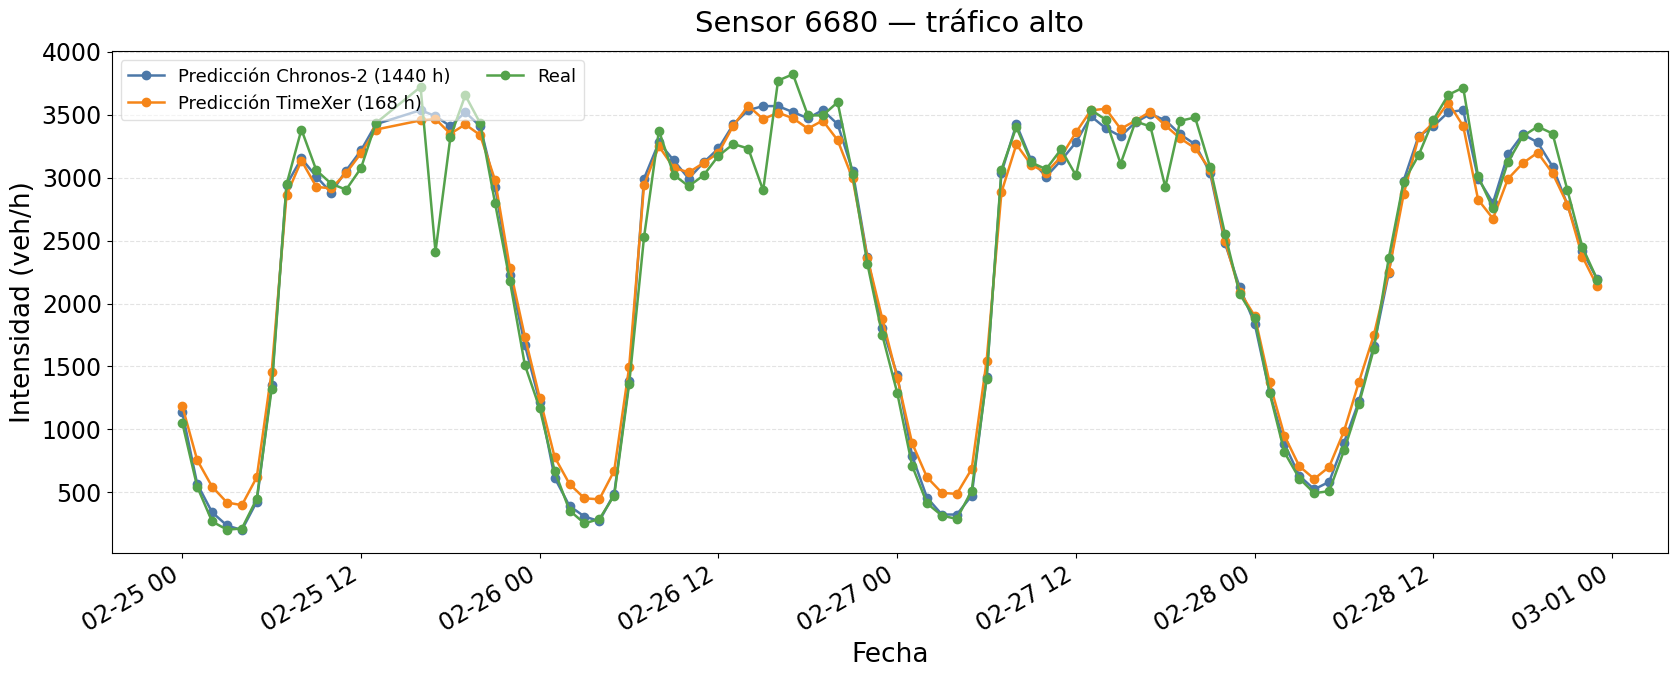

In [9]:
# ============================================================
# Figura 5.1.7: predicción vs real por sensor representativo
# Chronos-2 (1440H) vs TimeXer (168H) — una gráfica por sensor
# Datos: sensor_forecast_{chronos2_1440H,timexer_168H}.csv
# (volcados desde 4-chronos-2-PL96-HH1440 y 4-timexer-PL96-HH168).
# ============================================================

chr_f = pd.read_csv("sensor_forecast_chronos2_1440H.csv", parse_dates=["timestamp"])
tx_f  = pd.read_csv("sensor_forecast_timexer_168H.csv",  parse_dates=["timestamp"])

# Solo el tramo de predicción (se descarta el historial previo)
chr_f = chr_f[chr_f["segment"] == "forecast"]
tx_f  = tx_f[tx_f["segment"]  == "forecast"]

REAL_COLOR = "#54A24B"  # verde Vega, igual que en demanda agregada (retail)
sensor_labels = {"6716": "tráfico bajo", "6879": "tráfico medio", "6680": "tráfico alto"}

for sid in ["6716", "6879", "6680"]:
    c = chr_f[chr_f["sensor"].astype(str) == sid].sort_values("timestamp")
    t = tx_f[tx_f["sensor"].astype(str)  == sid].sort_values("timestamp")
    with plt.rc_context(MULTI_RC):
        fig, ax = plt.subplots(figsize=(17, 7))

        # Predicciones de cada modelo y la serie real (misma anchura; real encima)
        ax.plot(c["timestamp"], c["pred"], marker="o", color=colors["Chronos-2"], linewidth=1.8, label="Predicción Chronos-2 (1440 h)")
        ax.plot(t["timestamp"], t["pred"], marker="o", color=colors["TimeXer"],   linewidth=1.8, label="Predicción TimeXer (168 h)")
        ax.plot(c["timestamp"], c["actual"], marker="o", color=REAL_COLOR, linewidth=1.8, label="Real", zorder=5)

        ax.set_title(f"Sensor {sid} — {sensor_labels[sid]}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel("Intensidad (veh/h)")
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        ax.legend(loc="upper left", ncol=2, fontsize=13, framealpha=0.6)

        fig.autofmt_xdate()
        fig.tight_layout()
        fig.savefig(f"fig_5_1_7_forecast_sensor_{sid}_finalistas.png", dpi=300, bbox_inches="tight")
        plt.show()


### 5.1.8 Evolución de métricas por horizonte de predicción — finalistas (Chronos-2 1440H vs TimeXer 168H)

Comparativa unificada del error en función del horizonte de predicción (1–96 h), promediado sobre las 59 ventanas
rolling, para los dos modelos finalistas. Una gráfica por métrica (MAE, RMSE, MASE, WQL). La línea discontinua marca la
media de cada modelo sobre todos los horizontes. Replica el formato de la Figura 5.1.5 (evolución por ventana rolling).

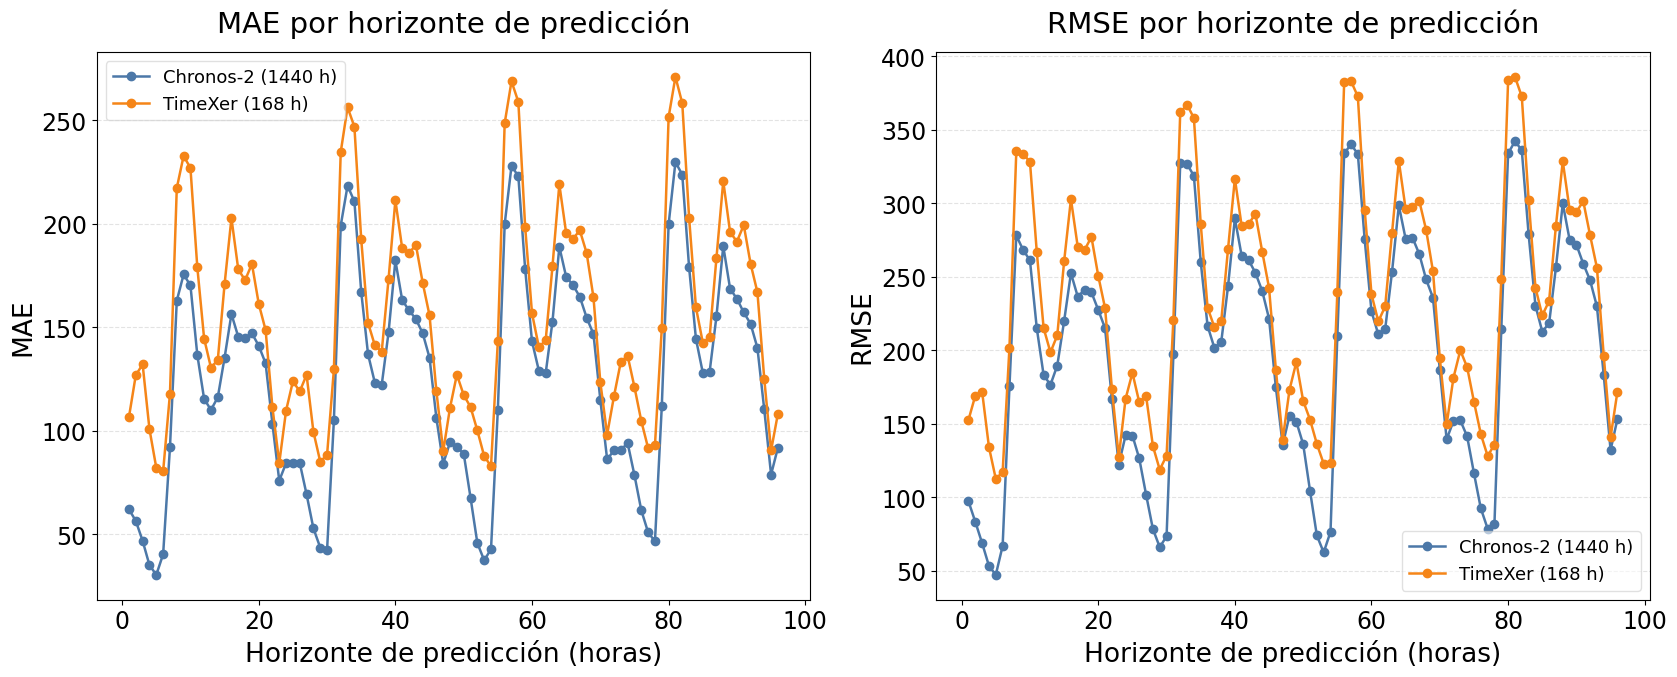

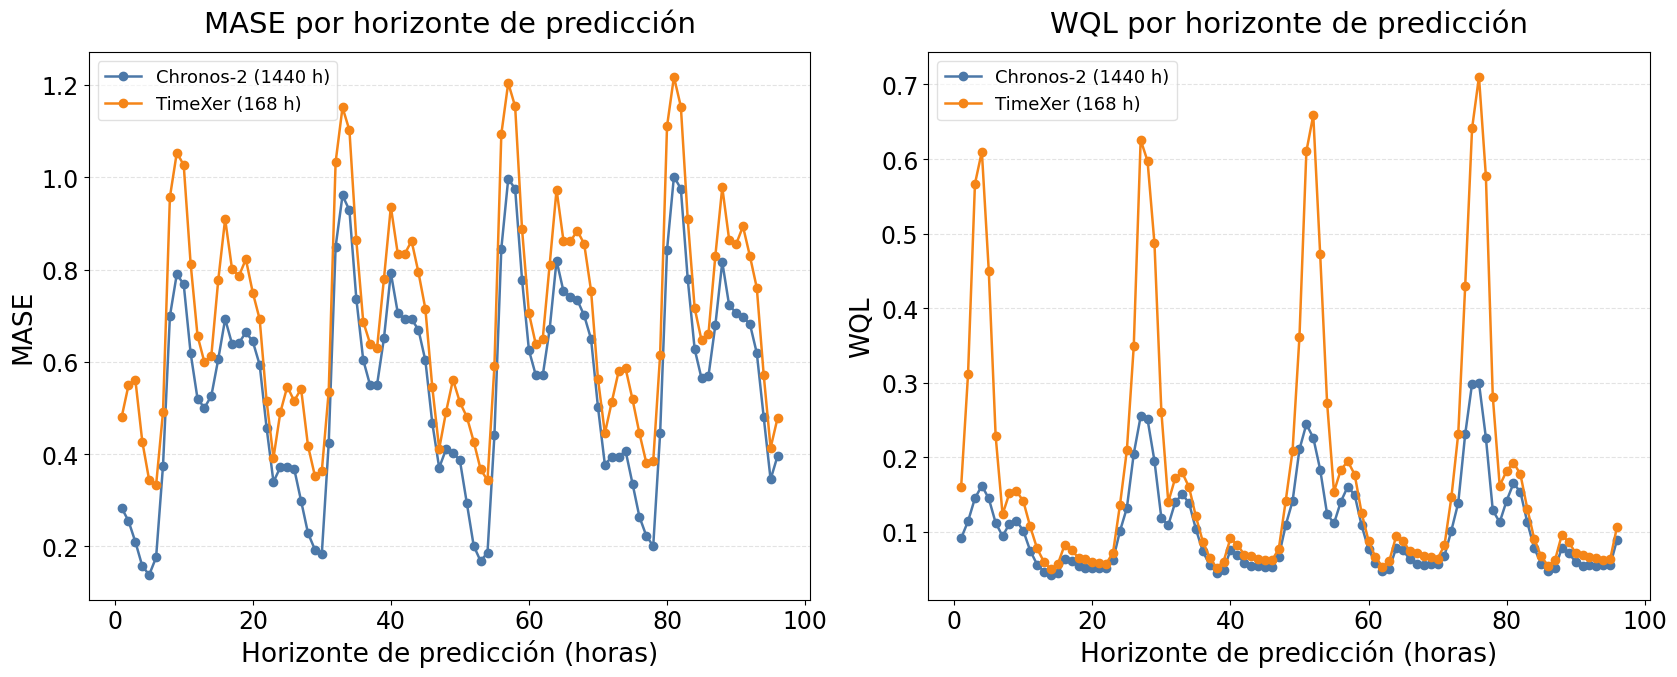

In [10]:
# ============================================================
# Figura 5.1.8: evolución de métricas por horizonte de predicción
# Chronos-2 (1440H) vs TimeXer (168H) — una gráfica por métrica
# Datos: horizon_window_metrics_{chronos2_1440H,timexer_168H}.csv
# (métricas por ventana×horizonte; se promedian sobre ventanas).
# ============================================================

hz_c = pd.read_csv("horizon_window_metrics_chronos2_1440H.csv")
hz_t = pd.read_csv("horizon_window_metrics_timexer_168H.csv")

metric_cols = ["MAE", "RMSE", "MASE", "WQL"]
mean_c = hz_c.groupby("horizon")[metric_cols].mean()
mean_t = hz_t.groupby("horizon")[metric_cols].mean()

series = {
    "Chronos-2 (1440 h)": (mean_c, colors["Chronos-2"]),
    "TimeXer (168 h)":    (mean_t, colors["TimeXer"]),
}

metric_pairs = [metric_cols[:2], metric_cols[2:]]  # 2 paneles por fila

for row_idx, pair in enumerate(metric_pairs):
    with plt.rc_context(MULTI_RC):
        fig, axes = plt.subplots(1, 2, figsize=(17, 7))

        for ax, metric in zip(axes, pair):
            for label, (mdf, color) in series.items():
                ax.plot(mdf.index, mdf[metric], marker="o", linewidth=1.8, color=color, label=label)

            ax.set_xlabel("Horizonte de predicción (horas)")
            ax.set_ylabel(metric)
            ax.set_title(f"{metric} por horizonte de predicción")
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.set_axisbelow(True)
            ax.legend(fontsize=13, framealpha=0.6)

        fig.tight_layout()
        fig.savefig(
            f"fig_5_1_8_horizonte_finalistas_r{row_idx + 1}.png",
            dpi=300, bbox_inches="tight",
        )
        plt.show()
